Précision (Accuracy) : 0.95
Matrice de confusion :
[[17  1]
 [ 0  2]]
Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.67      1.00      0.80         2

    accuracy                           0.95        20
   macro avg       0.83      0.97      0.89        20
weighted avg       0.97      0.95      0.95        20



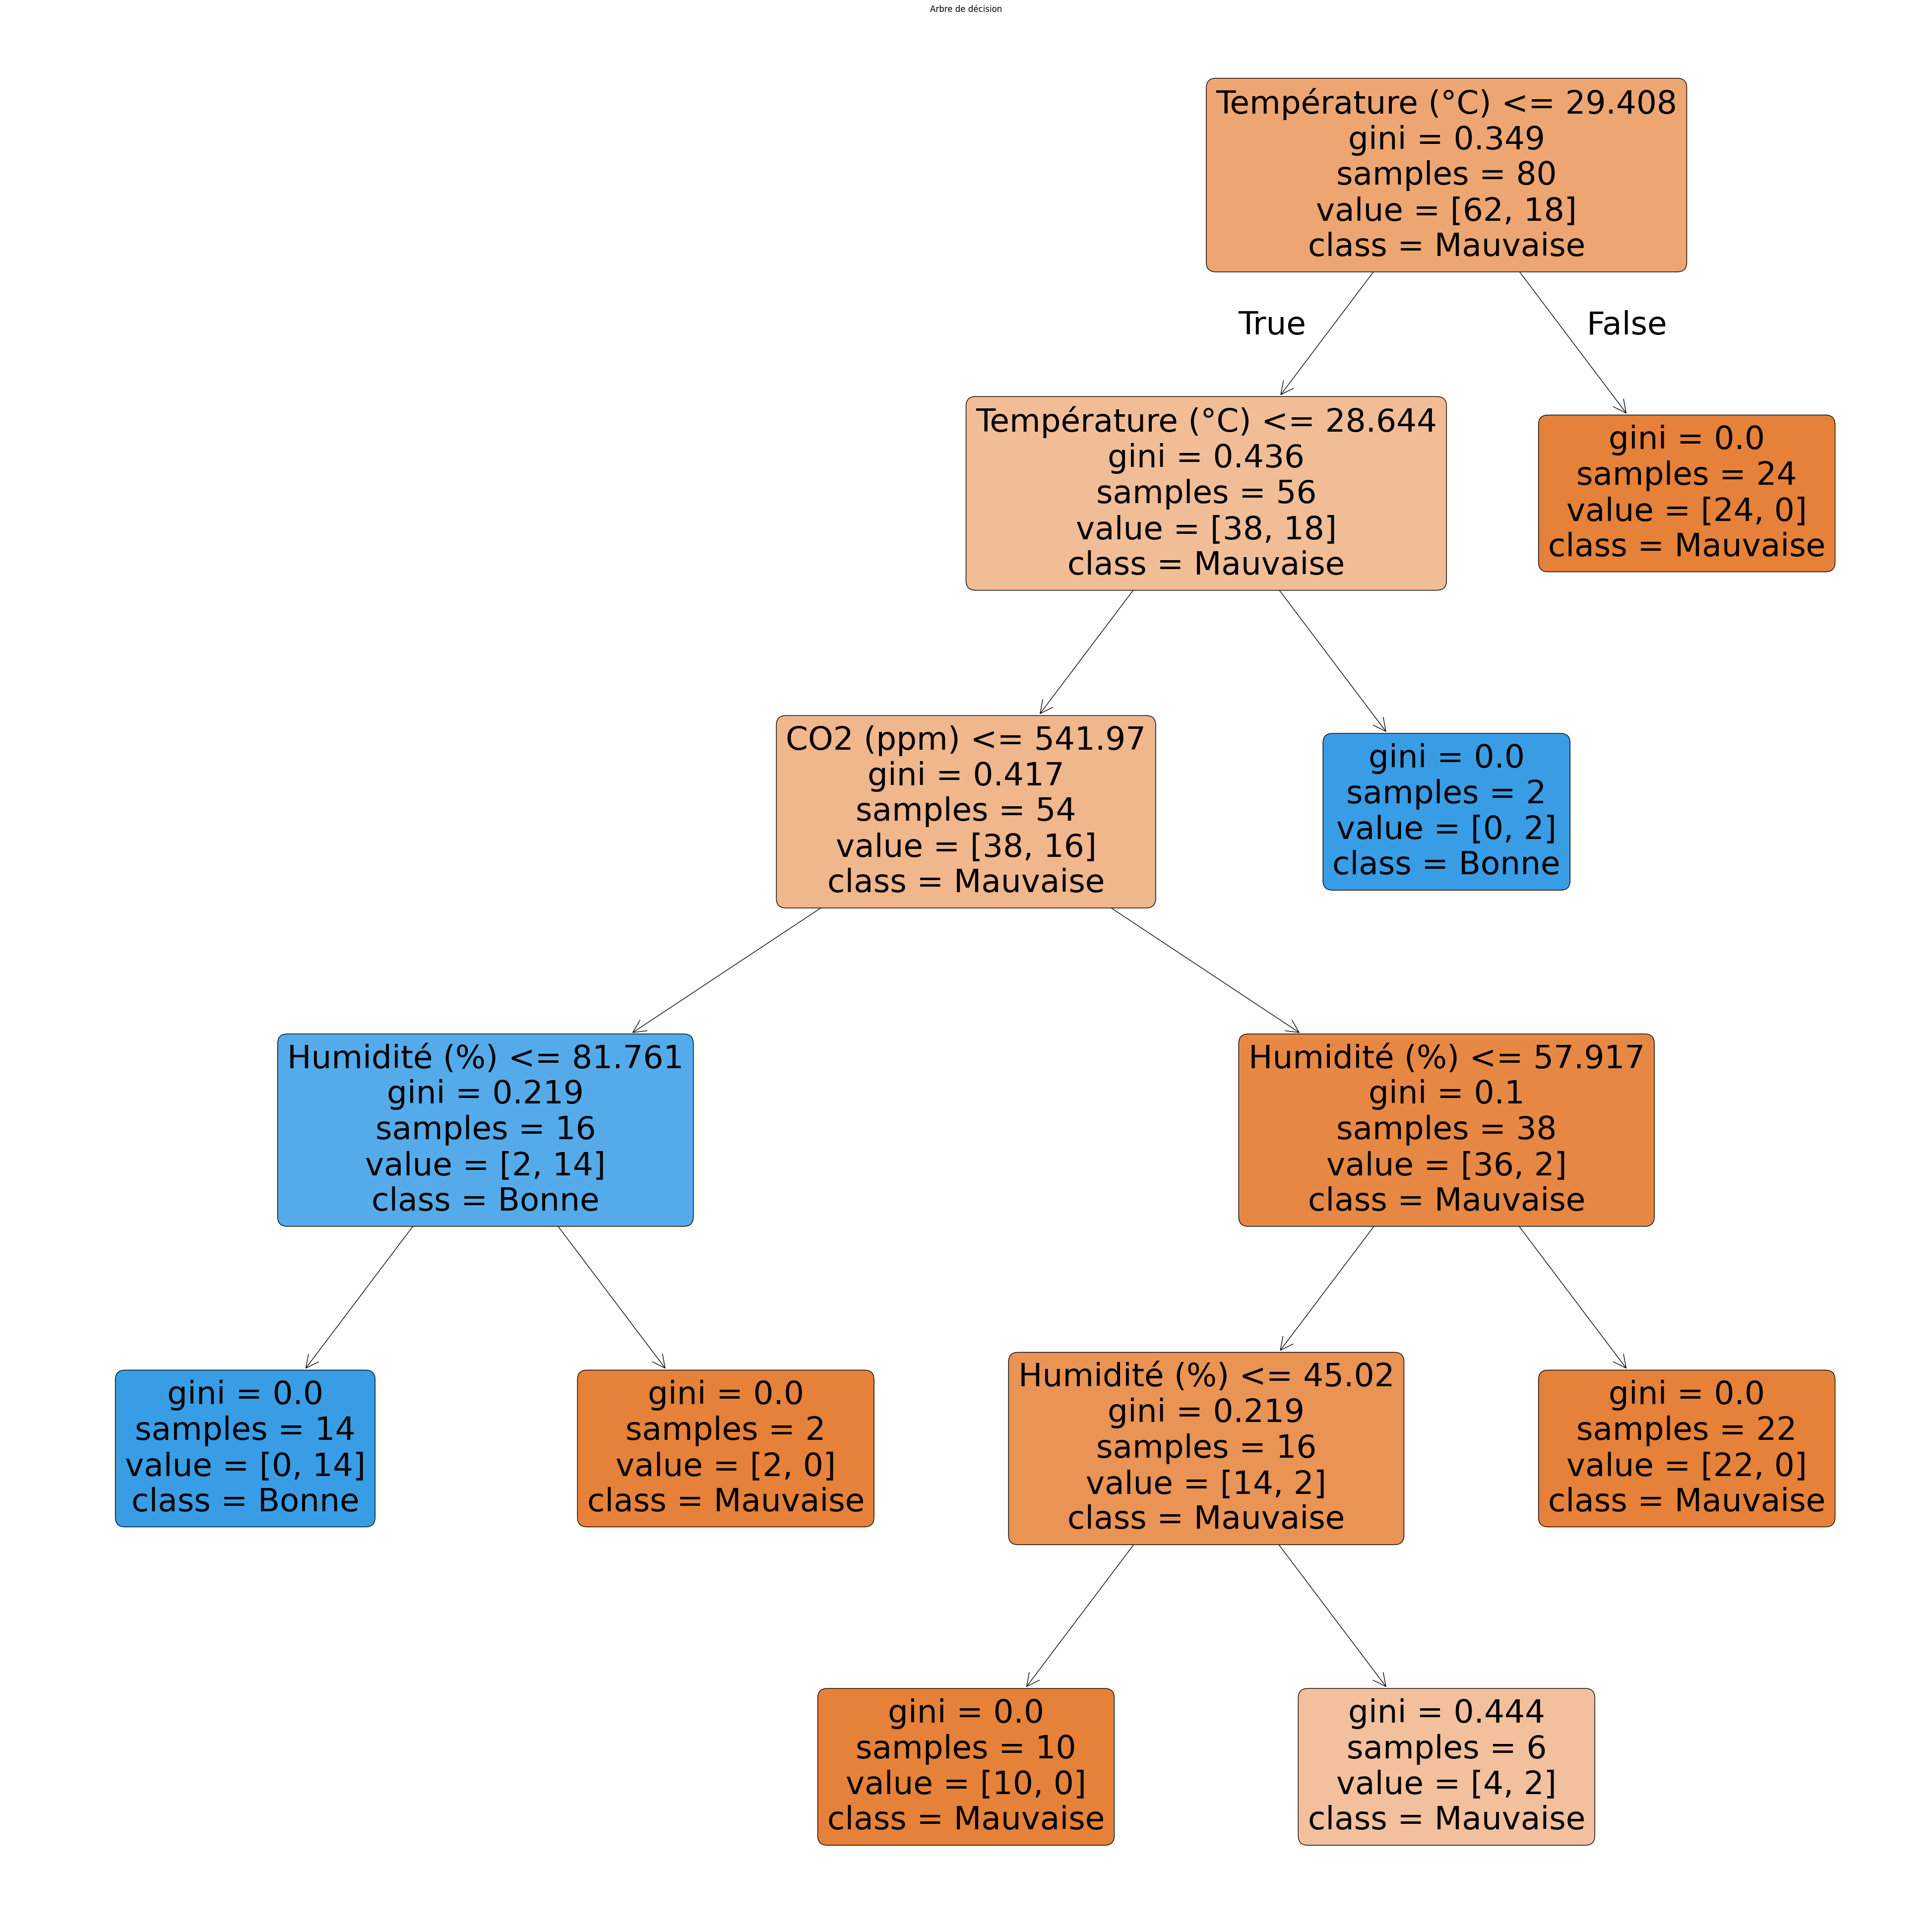

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

# 1. Charger les données
data = pd.read_csv('air_quality_dataset.csv')

# 2. Sélectionner les caractéristiques (X) et la cible (y)
X = data[['CO2 (ppm)', 'Température (°C)', 'Humidité (%)']]  # Variables indépendantes
y = data['Qualité de l\'air']  # Variable dépendante (cible)

# 3. Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Créer et entraîner le modèle d'arbre de décision
model = DecisionTreeClassifier(
    max_depth=5,               # Limiter la profondeur de l'arbre
    min_samples_split=5,      # Nombre minimal d'échantillons pour diviser un nœud
    min_samples_leaf=5,        # Nombre minimal d'échantillons dans une feuille
    max_features='sqrt',       # Nombre maximal de caractéristiques à considérer
    random_state=42            # Pour la reproductibilité
) # Vous pouvez ajuster les hyperparamètres si nécessaire
model.fit(X_train, y_train)

# 5. Faire des prédictions sur les données de test
y_pred = model.predict(X_test)

# 6. Évaluer les performances du modèle
# 6.1. Précision (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision (Accuracy) : {accuracy}")

# 6.2. Matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(conf_matrix)

# 6.3. Rapport de classification
class_report = classification_report(y_test, y_pred)
print("Rapport de classification :")
print(class_report)

# 7. Visualiser l'arbre de décision
plt.figure(figsize=(50, 50))
tree.plot_tree(model, feature_names=['CO2 (ppm)', 'Température (°C)', 'Humidité (%)'], 
               class_names=['Mauvaise', 'Bonne'], filled=True, rounded=True)  # Remplacer 'Mauvaise' et 'Bonne' par vos classes
plt.title("Arbre de décision")
plt.show()

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calcul des métriques
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Affichage des résultats
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9500
Precision: 0.9667
Recall: 0.9500
F1-score: 0.9543
